# 4. Embedded Methods: Regularization (L1) & Tree-Based Importance

So far, we have explored:
* **Filter Methods (Notebooks 1 & 2):** Feature evaluation completely independent of the final machine learning model.
* **Wrapper Methods (Notebook 3):** An external search wrapper training separate models repeatedly to find the optimal subset.

**Embedded Methods** perform feature selection **directly as part of the model training process**:
1. **Lasso ($L_1$ Penalty):** Automatically drives non-informative feature coefficients to exactly zero.
2. **Tree-Based Feature Importance (MDI / Gini Impurity):** Measures how much each feature splits the tree nodes.
3. **The High-Cardinality Trap:** Why default tree importance over-ranks noisy columns with many unique values.
4. **Permutation Importance:** The industry-standard alternative evaluated on holdout validation data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

np.random.seed(42)
n_samples = 1200

# 1. Synthesize a realistic customer churn dataset
# Informative numerical features:
monthly_bill = np.random.normal(70, 20, size=n_samples).clip(20, 150)
tenure_months = np.random.exponential(15, size=n_samples).clip(1, 72)
support_tickets = np.random.poisson(1.8, size=n_samples)

# Injected Noise Columns:
pure_noise_1 = np.random.normal(0, 1, size=n_samples)
pure_noise_2 = np.random.uniform(10, 50, size=n_samples)

# Pathological High-Cardinality Noise (e.g., Random Transaction ID / Hash)
# Pure noise, but has a unique value for almost every row
high_cardinality_noise = np.random.randint(100000, 999999, size=n_samples)

# 2. Target Generation (Churn)
churn_logits = (
    0.03 * monthly_bill 
    - 0.06 * tenure_months 
    + 0.5 * support_tickets 
    - 1.5
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn_target = (np.random.rand(n_samples) < churn_prob).astype(int)

df = pd.DataFrame({
    'Monthly_Bill': monthly_bill,
    'Tenure_Months': tenure_months,
    'Support_Tickets': support_tickets,
    'Noise_Num_1': pure_noise_1,
    'Noise_Num_2': pure_noise_2,
    'High_Card_Noise_ID': high_cardinality_noise,
    'Churn': churn_target
})

print("=== RAW DATASET WITH EMBEDDED PATHOLOGIES ===")
display(df.head())
print(f"Shape: {df.shape}")

=== RAW DATASET WITH EMBEDDED PATHOLOGIES ===


,Monthly_Bill,Tenure_Months,Support_Tickets,Noise_Num_1,Noise_Num_2,High_Card_Noise_ID,Churn
0,79.934283,1.000000,3,-0.739029,19.811172,444352,1
1,67.234714,15.042090,1,0.652330,27.936314,548032,0
2,82.953771,45.363008,2,1.427305,22.821447,468427,1
3,100.460597,13.804926,2,-0.419435,39.776770,185779,1
4,65.316933,25.654533,0,0.756488,48.848796,103060,0


Shape: (1200, 7)


---
## Step 1: Train / Test Split & Feature Scaling

**Critical Rule for Regularization ($L_1$ / Lasso):**
L1 regularization penalizes the absolute magnitude of coefficients: $\lambda \sum |w_j|$.
If features are on different scales (e.g., `Monthly_Bill` in tens vs. `High_Card_Noise_ID` in hundreds of thousands), the optimizer unfairly penalizes features with large raw numerical scales.
**Continuous features must always be standardized before applying Lasso.**

In [4]:
X = df.drop(columns=['Churn']).copy()
y = df['Churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features for fair coefficient penalties
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Features scaled successfully.")

Features scaled successfully.


---
## Step 2: $L_1$ Regularization (Lasso) Feature Selection

### The Mathematics Behind Lasso Zeroing:
* **Ridge ($L_2$):** Penalizes squared weights ($\lambda w^2$). It shrinks coefficients close to zero, but rarely sets them to *exactly* zero.
* **Lasso ($L_1$):** Penalizes absolute weights ($\lambda |w|$). Geometrically, the diamond-shaped constraint boundary forces non-informative weights directly to **$0.0$**, effectively dropping those columns from the model equation:

$$\hat{y} = \sigma(w_1 X_1 + 0 \cdot X_{\text{noise}} + w_3 X_3 + \dots)$$

In [5]:
# 1. Train Logistic Regression with L1 Penalty (Lasso)
# Solver 'liblinear' or 'saga' is required for L1 penalty
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso.fit(X_train_scaled, y_train)

# 2. Inspect the learned weights
df_lasso = pd.DataFrame({
    'Feature': X_train.columns,
    'L1_Coefficient': lasso.coef_[0]
}).sort_values(by='L1_Coefficient', key=abs, ascending=False).reset_index(drop=True)

print("=== LASSO COEFFICIENTS ===")
display(df_lasso)

# Notice how noise columns are driven down towards 0.0

=== LASSO COEFFICIENTS ===


d:\machine_learning_code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\machine_learning_code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Feature,L1_Coefficient
0,Tenure_Months,-0.723390
1,Monthly_Bill,0.544670
2,Support_Tickets,0.504149
3,High_Card_Noise_ID,0.047503
4,Noise_Num_2,-0.037048
5,Noise_Num_1,0.000000


---
## Step 3: Automated Selection Using `SelectFromModel`

Instead of manually checking which weights hit zero, Scikit-Learn's `SelectFromModel` meta-transformer extracts only the features whose weights exceed a given threshold.

In [6]:
# SelectFromModel keeps features where absolute weight > threshold
# threshold=1e-5 effectively drops any feature whose coefficient was driven to 0.0
selector_l1 = SelectFromModel(estimator=lasso, threshold=1e-5, prefit=True)

kept_mask = selector_l1.get_support()
selected_features_l1 = list(X_train.columns[kept_mask])
dropped_features_l1 = list(X_train.columns[~kept_mask])

print(f"Features Retained by Lasso: {selected_features_l1}")
print(f"Features Dropped to Zero:   {dropped_features_l1}")

Features Retained by Lasso: ['Monthly_Bill', 'Tenure_Months', 'Support_Tickets', 'Noise_Num_2', 'High_Card_Noise_ID']
Features Dropped to Zero:   ['Noise_Num_1']


---
## Step 4: Tree-Based Impurity (MDI) and the High-Cardinality Trap

Random Forests compute feature importance using **Mean Decrease in Impurity (MDI)**—measuring how much each feature split reduces Gini impurity across all decision trees.

### The Critical Flaw:
MDI is strongly biased toward **high-cardinality features** (features with many unique values, like random IDs). Even if an ID is pure noise, a decision tree can split on it repeatedly to isolate samples, awarding it an artificially high importance score.

In [7]:
# Train Random Forest on the unscaled training data (trees are scale-invariant)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extract default MDI feature importances
df_mdi = pd.DataFrame({
    'Feature': X_train.columns,
    'MDI_Importance': rf.feature_importances_
}).sort_values(by='MDI_Importance', ascending=False).reset_index(drop=True)

print("=== DEFAULT RANDOM FOREST MDI IMPORTANCE ===")
display(df_mdi)

# Notice: High_Card_Noise_ID scores deceptively high under MDI despite being 100% useless!

=== DEFAULT RANDOM FOREST MDI IMPORTANCE ===


,Feature,MDI_Importance
0,Tenure_Months,0.242917
1,Monthly_Bill,0.212265
2,Noise_Num_2,0.157099
3,High_Card_Noise_ID,0.154150
4,Noise_Num_1,0.143587
5,Support_Tickets,0.089982


---
## Step 5: Permutation Importance (The Production Fix)

### How Permutation Importance Works:
1. Train the model normally.
2. Evaluate performance on an unseen **validation/test set**.
3. Randomly shuffle the values of **one specific feature** (breaking its link to the target).
4. Re-evaluate the metric.
5. If the metric drops significantly $\rightarrow$ **The feature is genuinely predictive**.
6. If the metric doesn't change (or improves) $\rightarrow$ **The feature is useless noise**.

=== PERMUTATION IMPORTANCE (EVALUATED ON TEST DATA) ===


,Feature,Permutation_Importance_Mean,Permutation_Importance_Std
0,Tenure_Months,0.082500,0.021148
1,Support_Tickets,0.067917,0.015258
2,Monthly_Bill,0.063333,0.025331
3,High_Card_Noise_ID,0.032917,0.013235
4,Noise_Num_1,0.007500,0.007407
5,Noise_Num_2,0.005833,0.009718


C:\Users\DEVA\AppData\Local\Temp\ipykernel_24600\2574247272.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mdi, x='MDI_Importance', y='Feature', ax=axes[0], palette='Reds_r')
C:\Users\DEVA\AppData\Local\Temp\ipykernel_24600\2574247272.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perm, x='Permutation_Importance_Mean', y='Feature', ax=axes[1], palette='Greens_r')


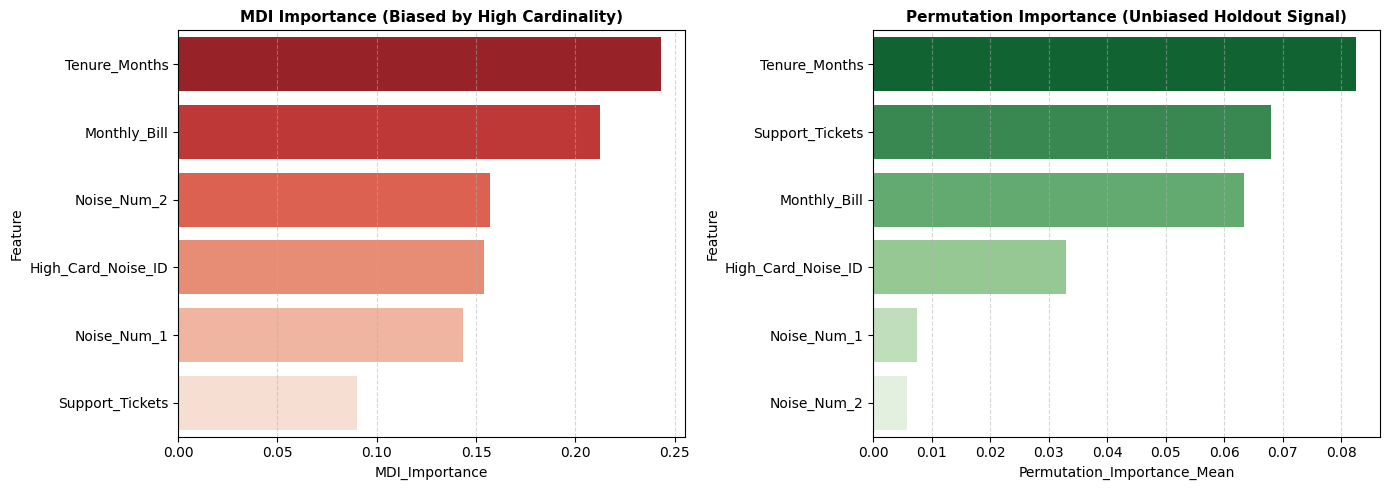

In [9]:
# Calculate permutation importance on the holdout test set
perm_result = permutation_importance(
    rf, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

df_perm = pd.DataFrame({
    'Feature': X_train.columns,
    'Permutation_Importance_Mean': perm_result.importances_mean,
    'Permutation_Importance_Std': perm_result.importances_std
}).sort_values(by='Permutation_Importance_Mean', ascending=False).reset_index(drop=True)

print("=== PERMUTATION IMPORTANCE (EVALUATED ON TEST DATA) ===")
display(df_perm)

# Compare MDI vs Permutation visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_mdi, x='MDI_Importance', y='Feature', ax=axes[0], palette='Reds_r')
axes[0].set_title("MDI Importance (Biased by High Cardinality)", fontsize=11, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.barplot(data=df_perm, x='Permutation_Importance_Mean', y='Feature', ax=axes[1], palette='Greens_r')
axes[1].set_title("Permutation Importance (Unbiased Holdout Signal)", fontsize=11, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Step 6: Test Performance Comparison

We evaluate `RandomForestClassifier` trained on:
1. All 6 features (including pure noise and misleading ID).
2. The clean 3-feature subset identified by Permutation Importance and Lasso.

In [10]:
# 1. Full feature set predictions
y_pred_full = rf.predict(X_test)

# 2. Retrain on the top 3 genuine features
top_features = ['Tenure_Months', 'Support_Tickets', 'Monthly_Bill']
rf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clean.fit(X_train[top_features], y_train)

y_pred_clean = rf_clean.predict(X_test[top_features])

print("=== 1. FULL DATASET (6 Features, with Noise & ID) ===")
print(classification_report(y_test, y_pred_full, target_names=['Retained (0)', 'Churned (1)']))

print("=== 2. EMBEDDED CLEAN SUBSET (3 Genuine Informative Features) ===")
print(classification_report(y_test, y_pred_clean, target_names=['Retained (0)', 'Churned (1)']))

=== 1. FULL DATASET (6 Features, with Noise & ID) ===
              precision    recall  f1-score   support

Retained (0)       0.70      0.50      0.58        90
 Churned (1)       0.74      0.87      0.80       150

    accuracy                           0.73       240
   macro avg       0.72      0.69      0.69       240
weighted avg       0.73      0.73      0.72       240

=== 2. EMBEDDED CLEAN SUBSET (3 Genuine Informative Features) ===
              precision    recall  f1-score   support

Retained (0)       0.61      0.52      0.56        90
 Churned (1)       0.74      0.80      0.77       150

    accuracy                           0.70       240
   macro avg       0.67      0.66      0.66       240
weighted avg       0.69      0.70      0.69       240



---
## Key Production Rules for Embedded Methods

1. **Lasso ($L_1$) requires feature scaling:** Unscaled features cause Lasso to penalize large-scale features unfairly rather than noisy ones.
2. **Tune Regularization Strength ($C$):** In Scikit-Learn, smaller $C$ means stronger regularization (more weights forced to zero).
3. **Beware of Tree MDI:** Never use default `rf.feature_importances_` to drop features if your dataset contains identifiers, timestamps, or high-cardinality categories.
4. **Use Permutation Importance for Verification:** Evaluate permutation importance on validation folds or holdouts to see the true impact on real-world generalization.